In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA')
from ESMCBA.imports import *
from ESMCBA import graph_utils

In [3]:
directory = '/global/scratch/users/sergiomar10/logs/ESMC_Pretrain_logs'
csv_files = glob.glob(os.path.join(directory, '*.csv'))
data = []

for file in csv_files:
    if os.path.getsize(file) > 0:
        try:
            df = pd.read_csv(file)
            base = os.path.basename(file)
            # Remove the file extension and split by underscore
            name_parts = os.path.splitext(base)[0].split('_')
            # Expected filename parts:
            # [0]: "training"
            # [1]: "log"
            # [2]: "ESMMASK"
            # [3]: encoding           (e.g., "HLA" or "epitope")
            # [4]: "FT"
            # [5]: blocks_unfrozen    (e.g., "25")
            # [6]: base_block_lr      (e.g., "0.0001")
            # [7]: regression_block_lr (e.g., "0.001")
            # [8]: "AUG"
            # [9]: num_augmentations  (e.g., "6")
            # [10]: HLA allele        (e.g., "HLAA3001")
            # [11]: (optional, e.g., replicate index)
            if len(name_parts) >= 11:
                encoding = name_parts[3]
                blocks_unfrozen = int(name_parts[5])
                base_block_lr = float(name_parts[6])
                regression_block_lr = float(name_parts[7])
                num_augmentations = int(name_parts[9])
                hla_allele = name_parts[10]
            else:
                encoding = 'Unknown'
                blocks_unfrozen = None
                base_block_lr = None
                regression_block_lr = None
                num_augmentations = None
                hla_allele = 'Unknown'
                
            max_val_acc = df['Val Acc'].max() if 'Val Acc' in df.columns else None
            
            data.append({
                'file': file,
                'filename': base,
                'encoding': encoding,
                'blocks_unfrozen': blocks_unfrozen,
                'base_block_lr': base_block_lr,
                'regression_block_lr': regression_block_lr,
                'num_augmentations': num_augmentations,
                'HLA_allele': hla_allele,
                'max_val_acc': max_val_acc
            })
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

df_summary = pd.DataFrame(data)


In [4]:
df_summary['HLA_allele'].value_counts().head(10)

HLA_allele
HLAB5101    80
HLAB5701    80
HLAB3901    75
HLAA0101    75
HLAA3001    73
HLAB4402    72
HLAB0801    71
HLAB1501    70
HLAA6801    69
HLAB1801    68
Name: count, dtype: int64

In [5]:
df_summary['BU_HLA'] = df_summary['base_block_lr'].astype(str) + ' + ' + df_summary['encoding'].astype(str)

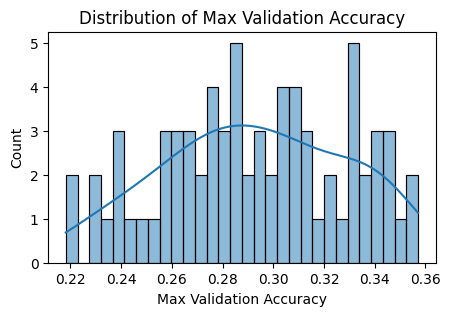

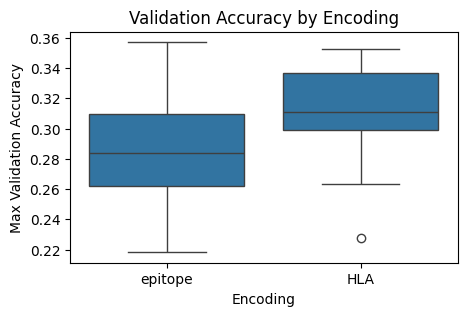

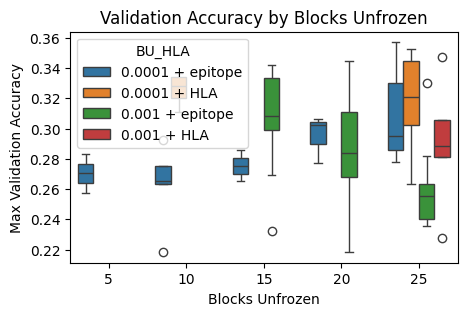

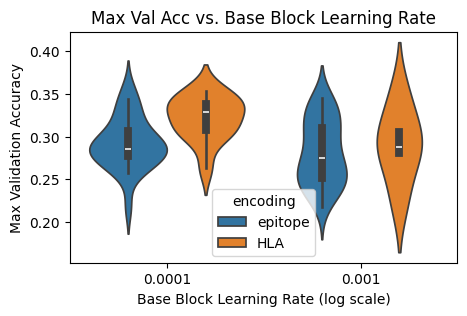

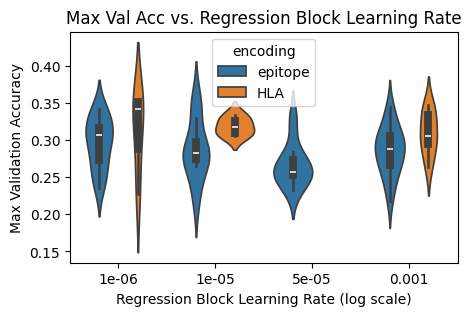

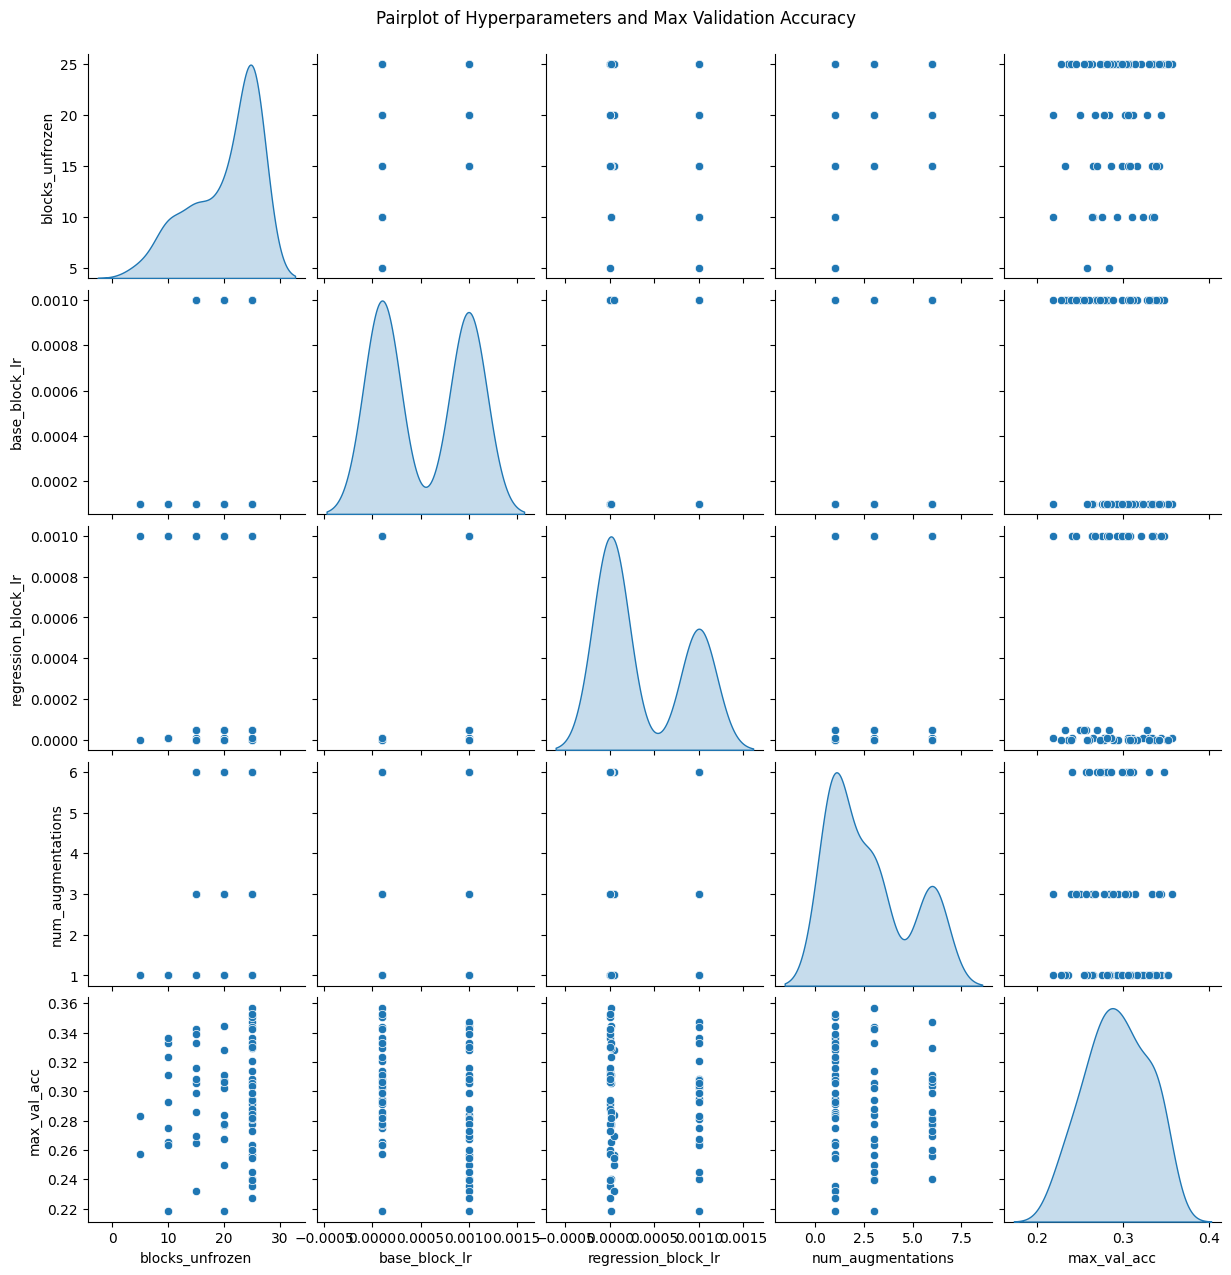

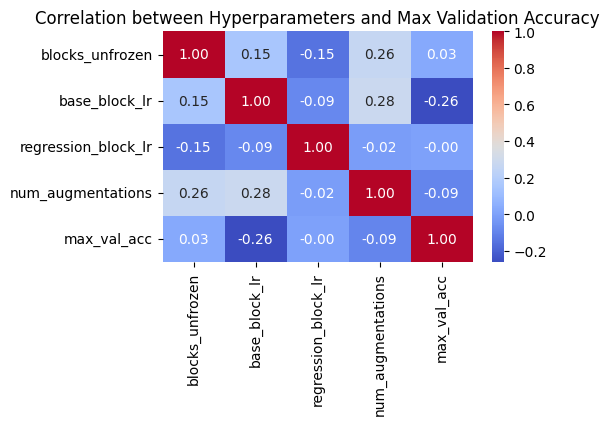

In [6]:
df_summary_subset = df_summary[df_summary['HLA_allele'] == 'HLAB4402' ]

# 1. Histogram of max_val_acc
plt.figure(figsize=(5, 3))
sns.histplot(df_summary_subset['max_val_acc'], bins=30, kde=True)
plt.title("Distribution of Max Validation Accuracy")
plt.xlabel("Max Validation Accuracy")
plt.ylabel("Count")
plt.show()

# 2. Boxplot: Max Val Acc by Encoding
plt.figure(figsize=(5, 3))
sns.boxplot(x='encoding', y='max_val_acc', data=df_summary_subset)
plt.title("Validation Accuracy by Encoding")
plt.xlabel("Encoding")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 3. Boxplot: Max Val Acc by Number of Unfrozen Blocks (if only a few distinct values)
plt.figure(figsize=(5, 3))
sns.boxplot(x='blocks_unfrozen', y='max_val_acc', hue='BU_HLA', data=df_summary_subset)
plt.title("Validation Accuracy by Blocks Unfrozen")
plt.xlabel("Blocks Unfrozen")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 4. Scatter Plot: Base Block LR vs. Max Val Acc (using log scale for lr)
plt.figure(figsize=(5, 3))
sns.violinplot(x='base_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Base Block Learning Rate")
plt.xlabel("Base Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 5. Scatter Plot: Regression Block LR vs. Max Val Acc (using log scale)
plt.figure(figsize=(5, 3))
sns.violinplot(x='regression_block_lr', y='max_val_acc', hue='encoding', data=df_summary_subset)
# plt.xscale('log')
plt.title("Max Val Acc vs. Regression Block Learning Rate")
plt.xlabel("Regression Block Learning Rate (log scale)")
plt.ylabel("Max Validation Accuracy")
plt.show()

# 6. Pairplot: Visualize all hyperparameters vs max_val_acc
selected_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
sns.pairplot(df_summary_subset[selected_cols], diag_kind='kde')
plt.suptitle("Pairplot of Hyperparameters and Max Validation Accuracy", y=1.02)
plt.show()

# 7. Correlation Heatmap: Numerical hyperparameters and performance
corr_cols = ['blocks_unfrozen', 'base_block_lr', 'regression_block_lr', 'num_augmentations', 'max_val_acc']
corr_matrix = df_summary_subset[corr_cols].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Hyperparameters and Max Validation Accuracy")
plt.show()


In [24]:
HLAs_done = Counter([x.split('HLA')[1].split('_')[0] for x in  glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/*.csv')]).keys()

In [110]:
import itertools

summary = []

for HLA in HLAs_done:

    # 1. Load all CSV files into a dictionary of DataFrames.
    trained_files = glob.glob(f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/*{HLA}*.csv')
    trained_files = sorted(trained_files)

    print(f"Found {len(trained_files)} files.")

    models = {}
    model_names = []
    for file in trained_files:

        if os.path.getsize(file) < 10:
            print(f"Skipping empty file: {file}")
            continue

        df = pd.read_csv(file)
        base = os.path.basename(file)
        # Remove common prefix and suffix to get a shorter model name.
        # For example: "training_log_ESMMASK_" and ".csv"
        name = base.replace("ESMMASK_epitope_", "").replace(".csv", "").split('_HLA')[0]
        models[name] = df
        model_names.append(name)

        # Summarize average token_nll for each model
        avg_nll = df['token_nll'].mean()

        summary.append({
        'File': os.path.basename(file),
        'HLA': HLA,
        'Avg_Token_NLL': avg_nll
    })
    # for name, df in models.items():
    #     avg_nll[name] = df['token_nll'].mean()

    # # Sort by lowest average negative log-likelihood
    # best_models_by_nll = sorted(avg_nll.items(), key=lambda x: x[1])
    # print("Best models by average token NLL:")
    # for name, score in best_models_by_nll:
    #     print(f"{name}: {score:.4f}")

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Avg_Token_NLL')
summary_df = summary_df[summary_df['Avg_Token_NLL'] > 0 ]


Found 27 files.
Found 7 files.
Found 9 files.
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAB61_1_per_token_metrics.csv
Found 8 files.
Found 41 files.
Found 10 files.
Found 13 files.
Found 7 files.
Found 10 files.
Found 13 files.
Found 10 files.
Found 7 files.
Found 11 files.
Found 38 files.
Found 6 files.
Found 8 files.
Found 37 files.
Found 10 files.
Found 31 files.
Found 10 files.
Found 12 files.
Found 7 files.
Found 7 files.
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_20_0.001_5e-05_AUG_1_HLAB3503_2_per_token_metrics.csv
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_25_0.001_1e-06_AUG_6_HLAB3503_1_per_token_metrics.csv
Found 37 files.
Skipping empty file: /global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/ESMMASK_epitope_FT_15_0.001_5e-0

<Axes: xlabel='HLA', ylabel='Avg_Token_NLL'>

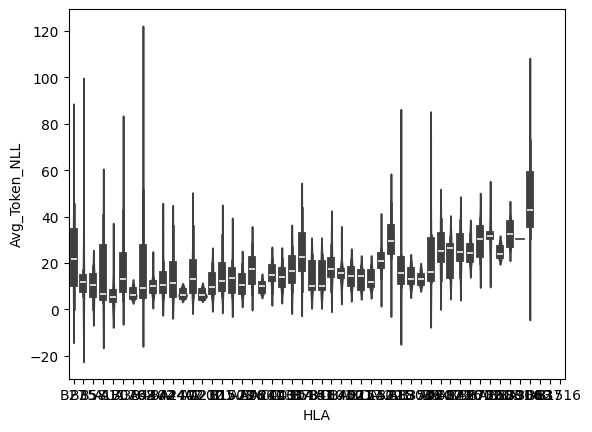

In [66]:
sns.violinplot(data = summary_df[summary_df['HLA'].isin(summary_df['HLA'].value_counts().reset_index().head(50)['HLA'])],
                x = 'HLA',
                y= 'Avg_Token_NLL')

Found 8 files.
Creating plots for 28 model pairs.


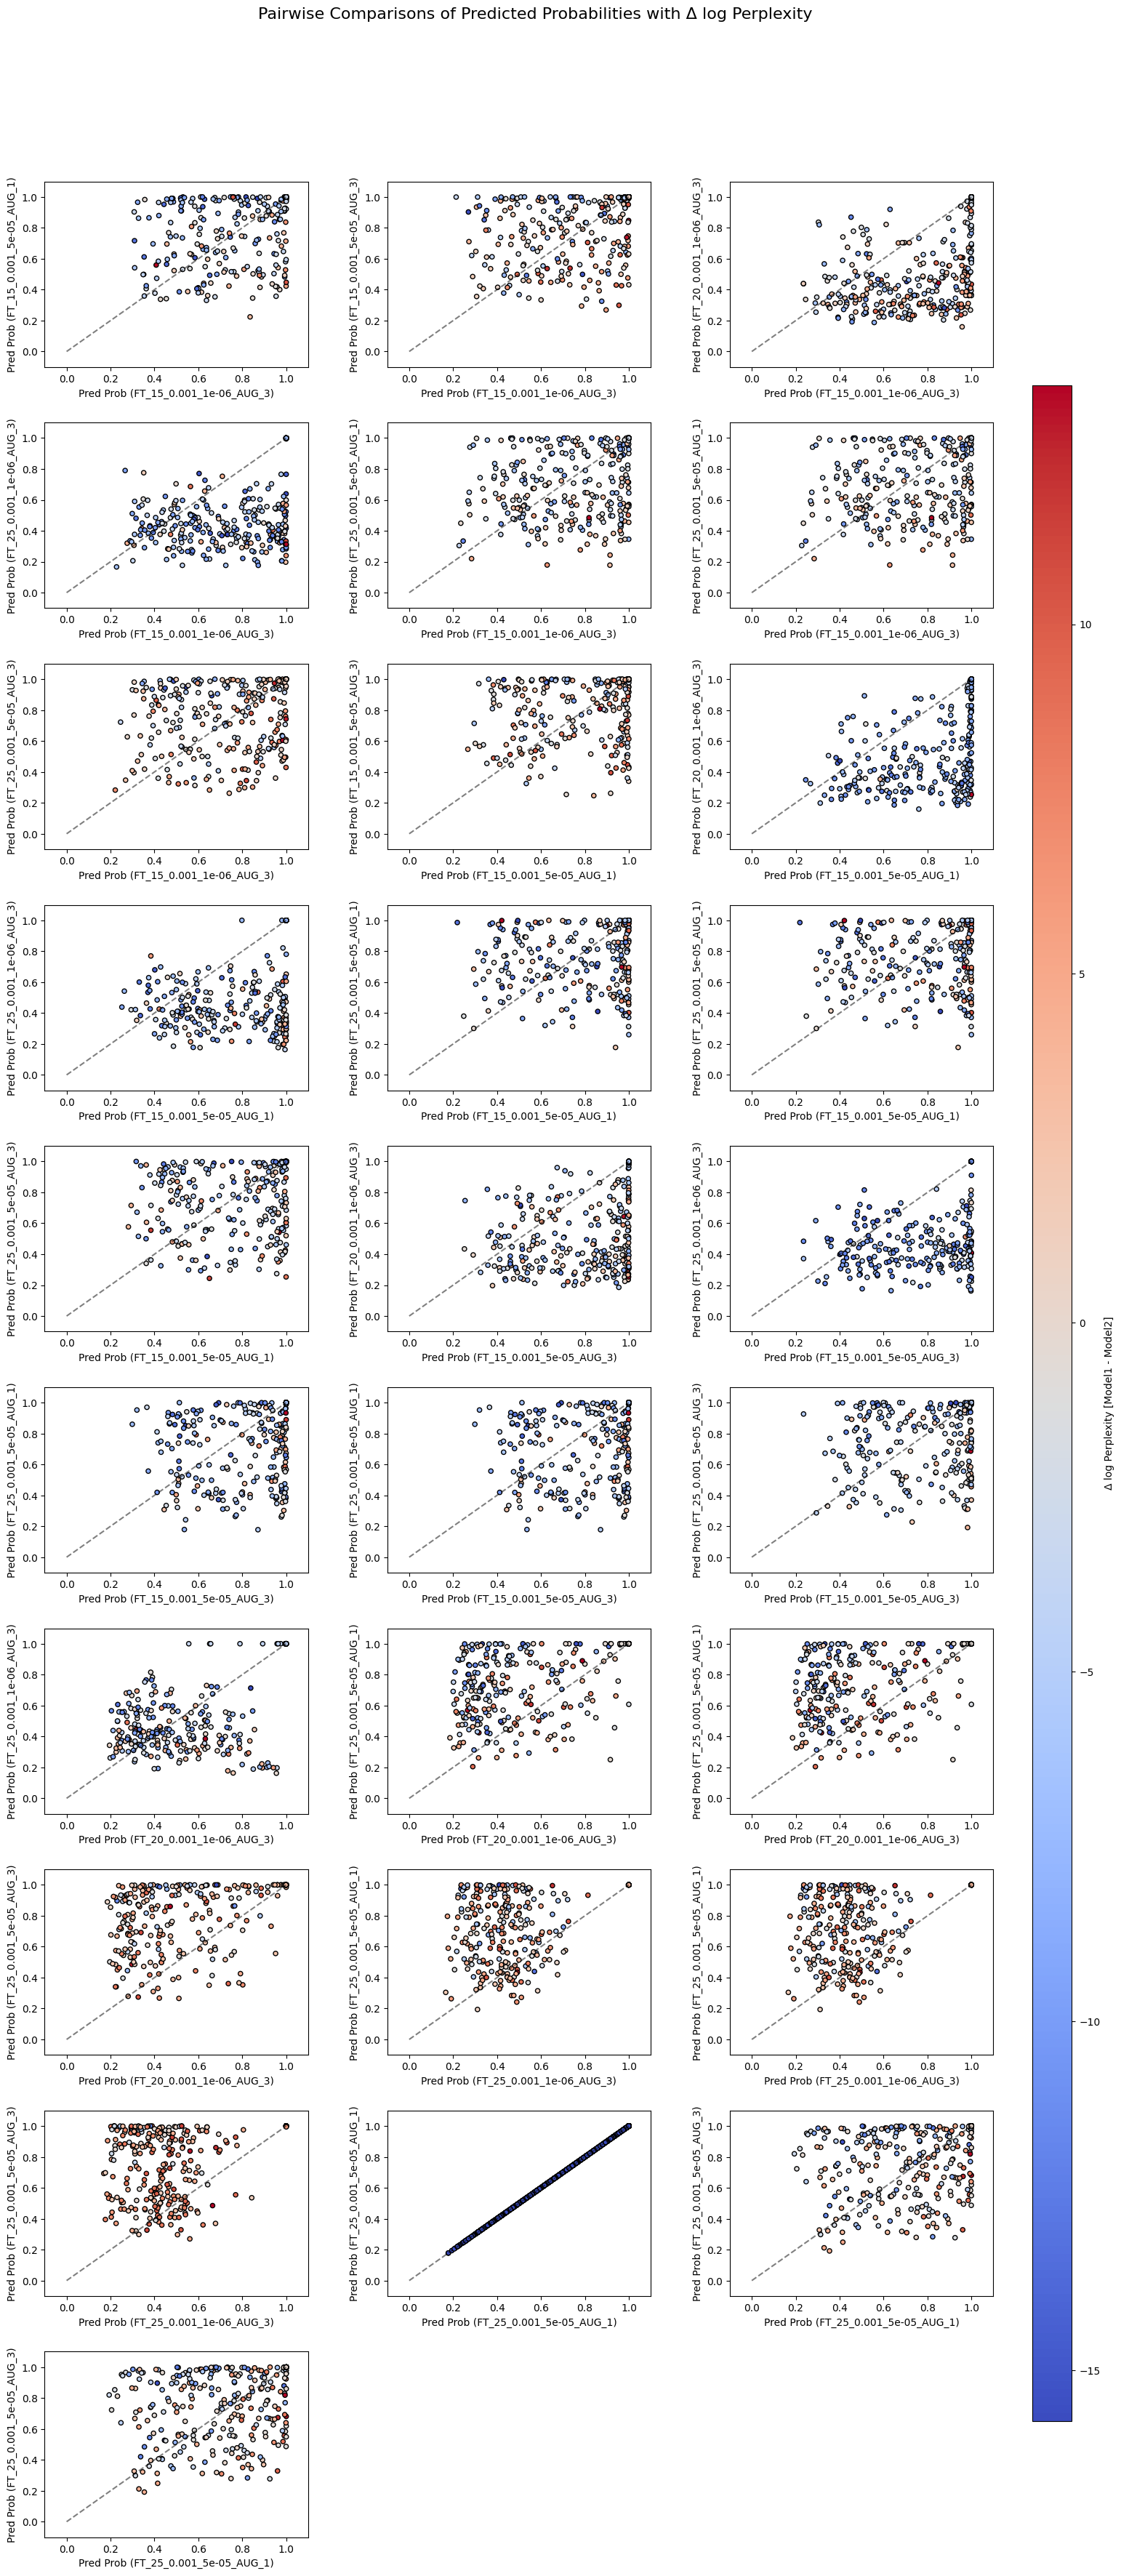

In [78]:
# 1. Load all CSV files into a dictionary of DataFrames.
trained_files = glob.glob('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_03042025_perplexity/*A0201*.csv')
trained_files = sorted(trained_files)
print(f"Found {len(trained_files)} files.")

models = {}
model_names = []
for file in trained_files:
    df = pd.read_csv(file)
    base = os.path.basename(file)
    # Remove common prefix and suffix to get a shorter model name.
    # For example: "training_log_ESMMASK_" and ".csv"
    name = base.replace("ESMMASK_epitope_", "").replace(".csv", "").split('_HLA')[0]
    models[name] = df
    model_names.append(name)

# Compute the common prefix across all model names.
# common_prefix = os.path.commonprefix(model_names)
# print("Common prefix:", common_prefix)

# Create a dictionary with trimmed names.
trimmed_models = {name: name for name in model_names}

# 2. Get a list of model names (original keys) and pairwise combinations.
pairs = list(itertools.combinations(model_names, 2))
n_pairs = len(pairs)
print(f"Creating plots for {n_pairs} model pairs.")

# 3. Create subplots for each pair.
n_cols = 3
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4), squeeze=False)

scatter_obj = None

for i, (model1, model2) in enumerate(pairs):
    # Merge on 'epitope' and 'position'
    df1 = models[model1]
    df2 = models[model2]
    df_merged = pd.merge(df1, df2, on=['epitope', 'position'], how='inner', 
                         suffixes=('_model1', '_model2'))
    
    # Compute Δ log perplexity (using token_nll directly as log perplexity)
    df_merged['delta_log_ppl'] = df_merged['token_nll_model1'] - df_merged['token_nll_model2']
    
    ax = axes[i // n_cols][i % n_cols]
    scatter_obj = ax.scatter(
        df_merged['predicted_prob_model1'],
        df_merged['predicted_prob_model2'],
        c=df_merged['delta_log_ppl'],
        cmap='coolwarm',
        s=20,
        edgecolor='k'
    )
    # Add a diagonal reference line.
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    
    # Use the trimmed names for labeling.
    x_label = trimmed_models[model1]
    y_label = trimmed_models[model2]
    ax.set_xlabel(f"Pred Prob ({x_label})")
    ax.set_ylabel(f"Pred Prob ({y_label})")
    # ax.set_title(f"{x_label} vs {y_label}")

# Remove empty subplots (if any)
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])

# 4. Add a single shared colorbar.
fig.suptitle("Pairwise Comparisons of Predicted Probabilities with Δ log Perplexity", fontsize=16)
fig.subplots_adjust(right=0.85, top=0.92, wspace=0.3, hspace=0.3)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(scatter_obj, cax=cbar_ax, label="Δ log Perplexity [Model1 - Model2]")

plt.show()

Text(0.5, 1.0, 'Histogram of Token-level NLLs')

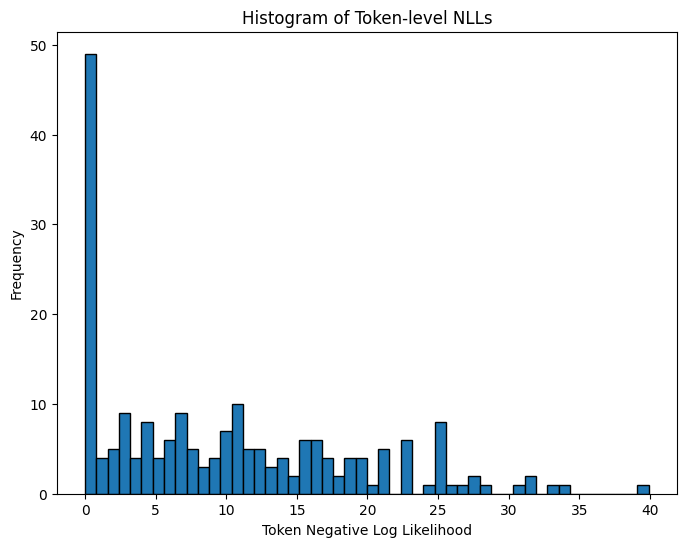

In [171]:
plt.figure(figsize=(8, 6))
plt.hist(df['token_nll'], bins=50, edgecolor='black')
plt.xlabel("Token Negative Log Likelihood")
plt.ylabel("Frequency")
plt.title("Histogram of Token-level NLLs")

In [111]:
directory = '/global/scratch/users/sergiomar10/models/ESMC_Pretrain/'
summary_df['model_path'] = directory + 'HLAHLA' + summary_df['HLA'] + '/' + summary_df['File'].str.replace('_per_token_metrics.csv','.pt')
# /global/scratch/users/sergiomar10/models/ESMC_Pretrain/HLAHLAB2703/ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB2703_2.pt

In [112]:
summary_df = summary_df[summary_df['HLA'].apply(len) > 4]

In [108]:
summary_df = summary_df.drop_duplicates('HLA').reset_index(drop=True)

In [119]:
summary_df

,File,HLA,Avg_Token_NLL,model_path
786,ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB27...,B2703,0.000004,/global/scratch/users/sergiomar10/models/ESMC_...
1135,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_1_HLAA02...,A0201,2.458064,/global/scratch/users/sergiomar10/models/ESMC_...
1607,ESMMASK_epitope_FT_20_0.001_1e-06_AUG_6_HLAA11...,A1101,3.082512,/global/scratch/users/sergiomar10/models/ESMC_...
1134,ESMMASK_epitope_FT_25_0.001_1e-06_AUG_3_HLAA02...,A0201,3.557103,/global/scratch/users/sergiomar10/models/ESMC_...
31,ESMMASK_epitope_FT_25_0.001_5e-05_AUG_3_HLAA31...,A3101,3.800563,/global/scratch/users/sergiomar10/models/ESMC_...
...,...,...,...,...
42,ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAB27...,B2704,inf,/global/scratch/users/sergiomar10/models/ESMC_...
45,ESMMASK_epitope_FT_20_0.001_1e-06_AUG_6_HLAB27...,B2704,inf,/global/scratch/users/sergiomar10/models/ESMC_...
47,ESMMASK_epitope_FT_25_0.001_1e-06_AUG_1_HLAB27...,B2704,inf,/global/scratch/users/sergiomar10/models/ESMC_...
48,ESMMASK_epitope_FT_25_0.001_1e-06_AUG_6_HLAB27...,B2704,inf,/global/scratch/users/sergiomar10/models/ESMC_...


In [118]:
summary_df.to_csv('file_paths.csv')

In [79]:
# sorted_acuraccies = []
# for file_name in glob.glob('/global/scratch/users/sergiomar10/models/ESMC_Pretrain/*/*.pt'):
#     try:
#         file_name = file_name.split('/')[-1].replace('.pt', '.csv')
#         file_name = f'/global/scratch/users/sergiomar10/data/ESMC_Pretrain/{file_name}'
#         eval_df = pd.read_csv(file_name)
#         eval_df = eval_df[eval_df['original_aa'] != '<eos>']
#         eval_df['correct'] = eval_df['original_aa'] == eval_df['predicted_aa']
#         size_of_eval_set = len(eval_df)
#         creation_time = os.path.getctime(file_name)
#         creation_date = datetime.datetime.fromtimestamp(creation_time)
#         acuraccy = len(eval_df[eval_df['correct'] == 1]) / len(eval_df)
#         sorted_acuraccies.append([file_name, creation_date, size_of_eval_set, acuraccy])
#     except:
#         print(file_name)

# eval_acc = pd.DataFrame(sorted_acuraccies, columns=['file', 'date', 'eval_set_size', 'accuracy'])
# eval_acc = eval_acc[eval_acc['accuracy'] < 0.8]

### Create SLURM files

In [10]:
################################################
# 6. Define a simple FASTA parser
################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        # Append the last sequence if present
        if seq:
            sequences.append((header, seq))
    return sequences


############################################
# 7. Load and filter the data
############################################
train_fasta = "/global/scratch/users/sergiomar10/jupyter_notebooks/hla_protein_sequences.fasta"
all_data = parse_fasta(train_fasta)

filtered_data = []
for header, sequence in all_data:
    if sequence[0] != 'M':
        continue
    if len(sequence) < 50:
        continue
    if 'X' in sequence:
        continue

    header = header.split('|')[1][:7].replace('*','').replace(':','')

    filtered_data.append(('HLA' + header))
    

In [59]:
import os

def sort_files_by_size(directory, descending=True):
    # List all items in the directory
    files = os.listdir(directory)
    # Filter only files (ignore directories)
    file_paths = [os.path.join(directory, f) for f in files if os.path.isfile(os.path.join(directory, f))]
    # Sort files by their size (in bytes)
    sorted_files = sorted(file_paths, key=os.path.getsize, reverse=descending)
    return sorted_files

# Example usage:
directory = "/clusterfs/nilah/sergio/iedb_sql_epitopes"
sorted_files = sort_files_by_size(directory)
# for file in sorted_files:
#     print(f"{file}: {os.path.getsize(file)} bytes")


In [61]:
HLAs = [x for x in hla_alleles if x.startswith('HLAA') or x.startswith('HLAB') or  x.startswith('HLAC')]

In [62]:
import itertools
import os
import glob

script_path = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/models/ESM_Unsupervised/ESM-C_ALLHLAs.py'
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/ESMC_pretrain3'
os.makedirs(sh_file_dir, exist_ok=True)

trials = [1, 2]
encoding = ['epitope']
blocks_unfrozen = [15, 20, 25]
last_block_lr = [1e-3]
regression_block_lr = [1e-6, 5e-5]
num_augmentations = [1, 3, 6]
                    
for trial_n, encode, num_block, lr_base, lr_reg, HLA, augs  in itertools.product(trials, encoding, blocks_unfrozen, last_block_lr, regression_block_lr, HLAs, num_augmentations):
    
    file_name = f'ESMMASK_{encode}_FT_{num_block}_{lr_base}_{lr_reg}_AUG_{augs}_{HLA}_{trial_n}'

    sh_filename = f'{file_name}.sh'
    sh_filepath = os.path.join(sh_file_dir, sh_filename)
    
    # Construct the command to run the script with the current parameters
    cmd = f'python3 {script_path} --name_of_model {file_name} --encoding {encode} --blocks_unfrozen {num_block} --base_block_lr {lr_base} --regression_block_lr {lr_reg} --HLA {HLA} --num_augmentations {augs}'

    with open(sh_filepath, 'w') as sh_file:
        sh_file.write('#!/bin/bash\n')
        sh_file.write('#SBATCH --account=co_nilah\n')
        sh_file.write('#SBATCH --partition=savio2_1080ti\n')
        sh_file.write('#SBATCH --qos=savio_lowprio\n')
        sh_file.write('#SBATCH --cpus-per-task=4\n')
        sh_file.write('#SBATCH --gres=gpu:1\n')
        sh_file.write('#SBATCH --requeue\n')
        sh_file.write('#SBATCH --time=03:00:00\n')
        sh_file.write(f'#SBATCH --job-name={file_name}\n')
        sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.out\n')
        sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/ESMC_Pretrain/{file_name}_%j.err\n')
        sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
        sh_file.write('\n')
        sh_file.write('conda activate ESM_cambrian\n')
        sh_file.write('\n')

        sh_file.write(cmd + '\n')
        
    # Make the shell script executable
    os.chmod(sh_filepath, 0o755)
    
    print(f'Created shell script: {file_name}')


Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA0201_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA0301_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAA1101_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_3_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_6_HLAB0702_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1e-06_AUG_1_HLAA6802_1
Created shell script: ESMMASK_epitope_FT_15_0.001_1